# k-NN & SVM — Distance and Margins

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (classification), Ames Housing (regression), 2D synthetic (for pictures)
**Goal:** Understand the two most important *non-tree* supervised algorithms — and why scaling makes or breaks them

---

## What Is This Notebook About?

Every other notebook in this series uses **tree-based** models (decision trees, random forests, boosting).
Trees are wonderful, but they are not the whole story. This notebook covers the two classic algorithms that
work on a completely different principle — **distance** and **geometry**:

- **k-Nearest Neighbors (k-NN):** "you are the average of your closest neighbors." To classify a new point,
  look at the *k* training points nearest to it and take a vote.
- **Support Vector Machines (SVM):** "find the widest possible street that separates the classes." SVM draws
  the boundary that leaves the largest margin between the two groups.

Both are **distance-based**, which leads to the single most important practical lesson in this notebook:

> **Distance-based models are useless without feature scaling.** We will *prove* this with a side-by-side demo.

---

## What You Will Learn

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | Libraries |
| 2 | Load Data | Adult (subsampled), Ames, and a 2D toy set |
| 3 | k-NN: The Idea | Lazy learning, majority vote among neighbors |
| 4 | Why Scaling Is Non-Negotiable | The demo that changes how you preprocess forever |
| 5 | Choosing k | The bias-variance knob for k-NN |
| 6 | k-NN Decision Boundaries | How k reshapes the regions (2D pictures) |
| 7 | Distance Weighting & the Curse of Dimensionality | When k-NN breaks down |
| 8 | k-NN for Regression | Averaging neighbor values |
| 9 | SVM: The Idea | Margins, support vectors, the widest street |
| 10 | The Kernel Trick | Linear vs RBF vs polynomial boundaries |
| 11 | The C Knob | Soft margins: how much to tolerate mistakes |
| 12 | The gamma Knob | How far each point's influence reaches |
| 13 | Tuning SVM | Grid search over C and gamma |
| 14 | SVM for Regression (SVR) | The epsilon-tube idea |
| 15 | k-NN vs SVM | When to reach for which |
| 16 | Summary | Decision guide + common mistakes |

---

## A Note on Reproducibility
We fix `random_state=42` everywhere. Because SVM and k-NN scale poorly to huge datasets (their cost grows
with the number of samples), we use a **stratified 4,000-row sample** of Adult — plenty to show every concept.

---


## Step 1 — Imports and Setup

Nothing exotic here. The two stars are `KNeighborsClassifier` and `SVC` (Support Vector Classifier), plus
their regression cousins `KNeighborsRegressor` and `SVR`. `StandardScaler` will turn out to be the most
important import in the whole notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml, make_moons, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# The models
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported.")


Libraries imported.


## Step 2 — Load Data

Three datasets:
- **Adult (classification)** — stratified 4,000-row sample, since SVM/k-NN are slow on large data.
- **Ames (regression)** — for the k-NN and SVM regression sections.
- **A 2D synthetic set** (`make_moons`) — two interleaving half-moons. We can't draw decision boundaries in
  12 dimensions, so we use this 2-feature toy to *see* what each model does.

We keep both a **raw** and a **scaled** copy of Adult so we can run the scaling demo in Step 4.


In [2]:
# ---- Adult (classification), 4k stratified sample ----
adult = fetch_openml('adult', version=2, as_frame=True).frame.drop(columns=['fnlwgt', 'education'])
y_all = (adult['class'].astype(str) == '>50K').astype(int)
Xa = adult.drop(columns=['class']).copy()
for c in Xa.select_dtypes(exclude='number').columns:
    Xa[c] = Xa[c].astype('category').cat.codes
Xa, _, ya, _ = train_test_split(Xa, y_all, train_size=4000, stratify=y_all, random_state=42)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    Xa, ya, test_size=0.2, random_state=42, stratify=ya
)
# Scaled versions (fit the scaler on TRAIN only, then apply to both — no leakage)
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print(f"Adult classification — train {X_train.shape}, test {X_test.shape}")

# ---- Ames (regression) ----
ames = fetch_openml('house_prices', as_frame=True).frame
y_house = ames['SalePrice'].astype(float)
X_house = ames.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()
for c in X_house.select_dtypes(include='number').columns:
    X_house[c] = X_house[c].fillna(X_house[c].median())
for c in X_house.select_dtypes(exclude='number').columns:
    X_house[c] = X_house[c].astype('object').fillna('None').astype('category').cat.codes
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)
print(f"Ames regression      — train {Xh_train.shape}, test {Xh_test.shape}")

# ---- 2D toy for drawing decision boundaries ----
X2d, y2d = make_moons(n_samples=400, noise=0.25, random_state=42)
X2d_tr, X2d_te, y2d_tr, y2d_te = train_test_split(X2d, y2d, test_size=0.3, random_state=42)
print(f"2D synthetic (make_moons) — {X2d.shape[0]} points, 2 features")


Adult classification — train (3200, 12), test (800, 12)
Ames regression      — train (1168, 79), test (292, 79)
2D synthetic (make_moons) — 400 points, 2 features


## Step 3 — k-Nearest Neighbors: The Idea

k-NN is the simplest idea in machine learning, and it barely counts as "training":

1. **"Training"** just means *memorizing* the training data. That's it — no equations solved, no weights
   learned. This is why k-NN is called a **lazy learner**.
2. **Predicting** a new point: measure the distance from it to *every* training point, find the **k closest**
   ("nearest neighbors"), and take a **majority vote** of their labels.

> **Everyday analogy:** to guess whether a new restaurant is good, you look at the 5 most similar restaurants
> you know and go with the majority verdict. k-NN does exactly that, with "similar" meaning "close in feature space."

**Two consequences of being distance-based:**
- **Scaling matters enormously** (Step 4) — a feature measured in the thousands will drown out one measured
  in single digits.
- **Prediction is slow on big data** — every prediction compares against all training points.


In [3]:
# A first k-NN with k=5 on the SCALED Adult data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)                     # "fit" just stores the training data
acc = accuracy_score(y_test, knn.predict(X_test))
print(f"k-NN (k=5, scaled features) test accuracy: {acc:.4f}")


k-NN (k=5, scaled features) test accuracy: 0.8125


## Step 4 — Why Scaling Is Non-Negotiable

This is the most important experiment in the notebook. k-NN measures **distance**, and distance is dominated
by whichever feature has the largest numeric range. To see this cleanly, we take our 2D half-moons and put the
two features on **very different scales** — we multiply feature 2 by 100, as if it were measured in different
units (think *grams* vs *kilograms*, or *age in years* vs *income in dollars*). Both features are equally
informative here, so any accuracy lost is purely the scaling's fault.

We then train the **exact same k-NN** twice — on the raw (stretched) data and on the scaled data.


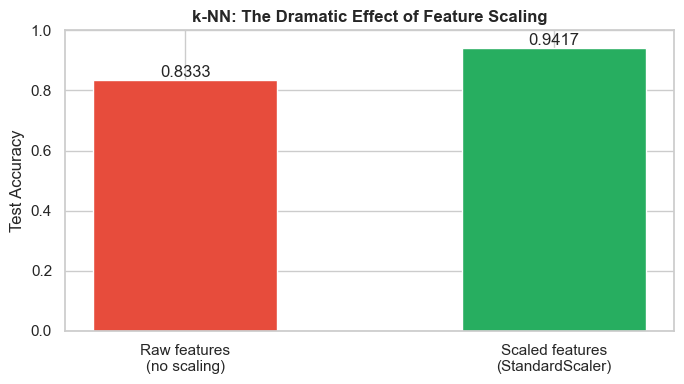

Raw (feature 2 stretched x100): 0.8333
Scaled:                         0.9417
Scaling improved accuracy by +0.1083 — same model, same data, same k.
Unscaled, the stretched feature 2 dominates every distance and feature 1 is ignored.


In [4]:
# Put the two (equally informative) features on wildly different scales: feature 2 x 100.
X2d_stretch = X2d.copy()
X2d_stretch[:, 1] = X2d_stretch[:, 1] * 100.0    # e.g. feature 2 now measured in different units
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X2d_stretch, y2d, test_size=0.3, random_state=42)

# Same model, same k=5 — the ONLY difference is whether we scale first.
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xs_tr, ys_tr)
acc_raw = accuracy_score(ys_te, knn_raw.predict(Xs_te))
# make_pipeline scales on the training folds only, then applies to test — the leak-free way.
knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xs_tr, ys_tr)
acc_scaled = accuracy_score(ys_te, knn_scaled.predict(Xs_te))

plt.figure(figsize=(7, 4))
bars = plt.bar(['Raw features\n(no scaling)', 'Scaled features\n(StandardScaler)'],
               [acc_raw, acc_scaled], color=['#e74c3c', '#27ae60'], edgecolor='white', width=0.5)
for bar, v in zip(bars, [acc_raw, acc_scaled]):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=12)
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.title('k-NN: The Dramatic Effect of Feature Scaling', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Raw (feature 2 stretched x100): {acc_raw:.4f}")
print(f"Scaled:                         {acc_scaled:.4f}")
print(f"Scaling improved accuracy by {acc_scaled - acc_raw:+.4f} — same model, same data, same k.")
print("Unscaled, the stretched feature 2 dominates every distance and feature 1 is ignored.")


### How to Read This Chart: The Effect of Scaling

- **Red bar** = k-NN on raw, unscaled features. **Green bar** = the identical k-NN on scaled features.
- The only thing that changed is whether we ran `StandardScaler` first — yet the accuracy jumps.
- **Why:** on raw data, the one large-range feature (the x100 one) dominates every distance calculation, so
  the model effectively ignores the other feature. Scaling gives every feature an equal vote.

> **The rule to remember:** always scale features for k-NN, SVM, and any distance- or gradient-based model.
> (Tree models are the exception — they split on thresholds, so scale doesn't affect them.)


## Step 5 — Choosing k: The Bias-Variance Knob

`k` (the number of neighbors) is k-NN's main hyperparameter, and it directly controls the
**bias-variance tradeoff** you met in the decision-trees notebook:

- **Small k (e.g. k=1):** the prediction follows the single nearest point. Super flexible, but it chases
  noise — **low bias, high variance (overfitting)**. The boundary is jagged.
- **Large k (e.g. k=200):** the prediction averages a huge neighborhood, smoothing over real structure —
  **high bias, low variance (underfitting)**.
- **The sweet spot** is in between, and we find it by trying many values.


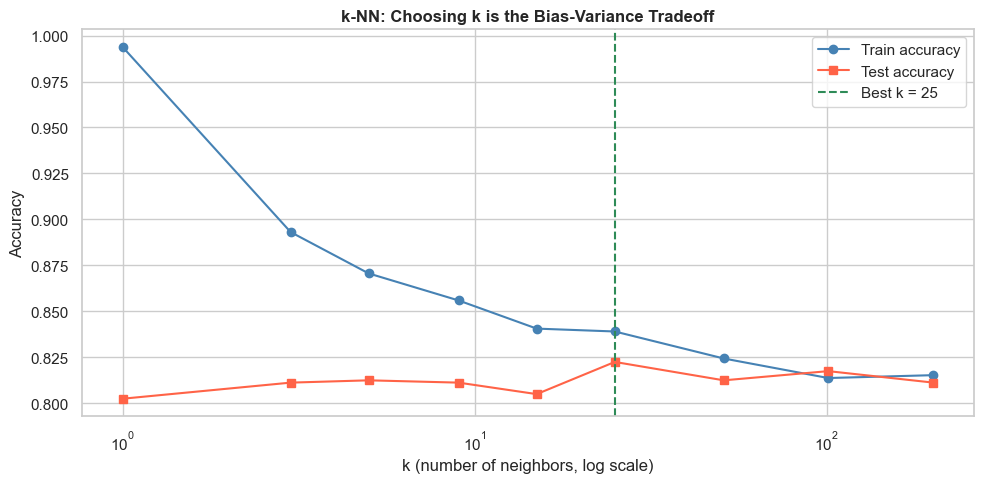

Best test accuracy 0.8225 at k=25


In [5]:
ks = [1, 3, 5, 9, 15, 25, 51, 101, 201]
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

best_k = ks[int(np.argmax(test_acc))]
plt.figure(figsize=(10, 5))
plt.plot(ks, train_acc, 'o-', color='steelblue', label='Train accuracy')
plt.plot(ks, test_acc, 's-', color='tomato', label='Test accuracy')
plt.axvline(best_k, color='seagreen', ls='--', label=f'Best k = {best_k}')
plt.xscale('log')
plt.xlabel('k (number of neighbors, log scale)')
plt.ylabel('Accuracy')
plt.title('k-NN: Choosing k is the Bias-Variance Tradeoff', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Best test accuracy {max(test_acc):.4f} at k={best_k}")


### How to Read This Chart: Choosing k

- **X-axis** = k, on a log scale (from 1 neighbor up to 201).
- **Blue line (train)**: at k=1 it's ~100% — each training point is its own nearest neighbor, so it's always
  "right" on training data. This is the classic overfitting signature.
- **Red line (test)**: the only line that matters. It's low at k=1 (overfitting), rises to a peak (the sweet
  spot), then falls again for very large k (underfitting — the neighborhood is so big it just predicts the
  majority class).
- **Green dashed line** = the k with the best test accuracy.

> **Reading direction:** left = too flexible (high variance), right = too rigid (high bias). You want the top
> of the red curve. Odd k values avoid ties in binary voting.


## Step 6 — k-NN Decision Boundaries (2D Pictures)

Numbers are abstract; let's *see* what k does. Using our 2D half-moons toy, we draw the decision boundary for
several values of k. Watch it go from jagged (overfit) to smooth (underfit).


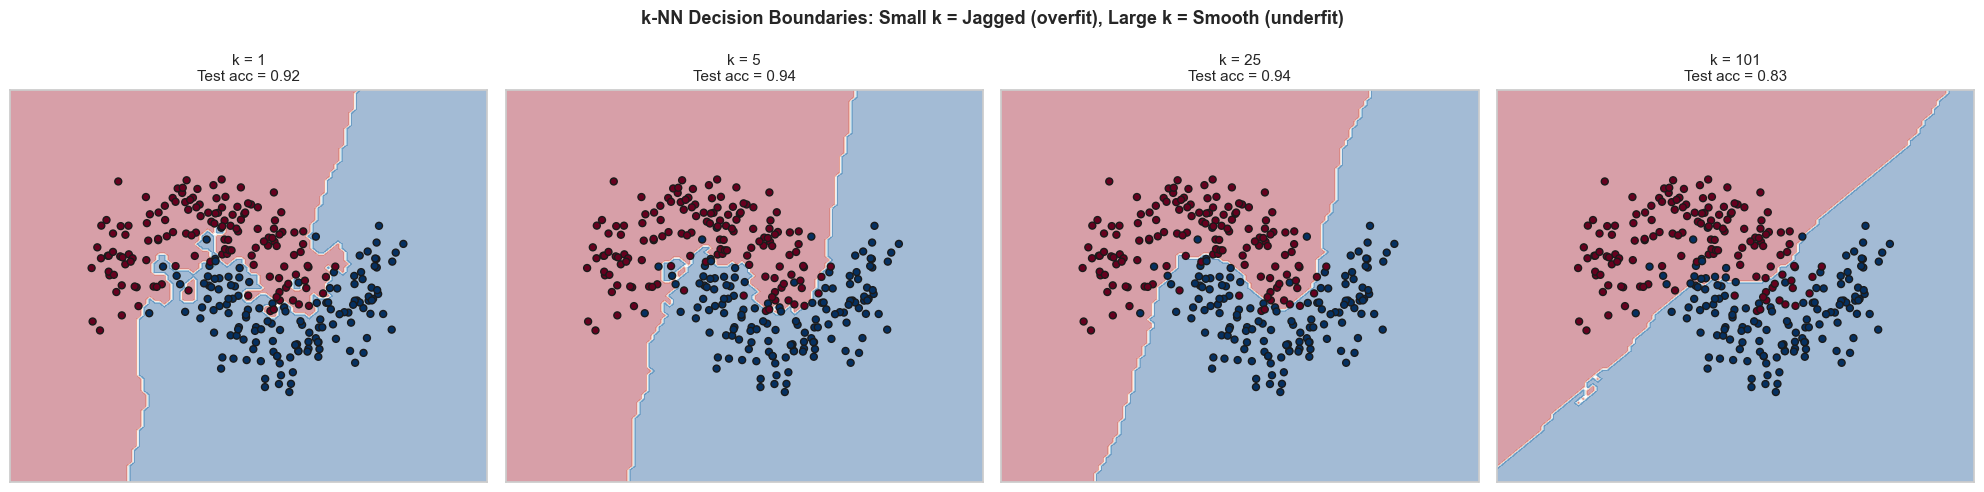

In [6]:
ks_plot = [1, 5, 25, 101]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, k in zip(axes, ks_plot):
    m = KNeighborsClassifier(n_neighbors=k).fit(X2d_tr, y2d_tr)
    DecisionBoundaryDisplay.from_estimator(m, X2d, alpha=0.4, ax=ax, cmap='RdBu', response_method='predict')
    ax.scatter(X2d_tr[:, 0], X2d_tr[:, 1], c=y2d_tr, cmap='RdBu', edgecolors='k', s=25)
    acc = accuracy_score(y2d_te, m.predict(X2d_te))
    ax.set_title(f'k = {k}\nTest acc = {acc:.2f}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('k-NN Decision Boundaries: Small k = Jagged (overfit), Large k = Smooth (underfit)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: k-NN Boundaries

- **Background color** = the region each class "owns." **Dots** = training points, colored by true class.
- **k = 1:** the boundary wraps tightly around individual points, creating little islands — it has memorized
  the noise. **Overfitting** made visible.
- **k = 5 to 25:** the boundary smooths into the true two-moon shape — this is the healthy middle.
- **k = 101:** the boundary is over-smoothed and starts cutting through the moons — **underfitting**.

> **The same jagged→smooth story as the accuracy curve, now as a picture.** This is *why* the test-accuracy
> curve peaks in the middle.


## Step 7 — Distance Weighting & the Curse of Dimensionality

**Two important refinements and one warning:**

**Distance weighting.** By default all k neighbors vote equally. With `weights='distance'`, closer neighbors
get a bigger say. It often helps a little (and makes ties impossible), though not always — on some datasets
plain uniform voting is already as good, as you may see below. It is worth trying, not assuming.

**The curse of dimensionality (the warning).** k-NN relies on "near" being meaningful. In *high* dimensions,
something bizarre happens: **all points become roughly equidistant from each other**, so "nearest" stops
meaning "most similar." This is why k-NN struggles on datasets with hundreds of features. The quick demo
below shows distances bunching up as dimensions grow.


In [7]:
# Uniform-weight vs distance-weight k-NN
for w in ['uniform', 'distance']:
    m = KNeighborsClassifier(n_neighbors=best_k, weights=w).fit(X_train, y_train)
    print(f"  weights='{w}': test accuracy {accuracy_score(y_test, m.predict(X_test)):.4f}")

# Curse of dimensionality: how similar are the nearest and farthest points as dimensions grow?
print("\nCurse of dimensionality — ratio of (nearest distance) to (farthest distance):")
rng = np.random.RandomState(42)
for dim in [2, 10, 50, 200, 1000]:
    pts = rng.rand(500, dim)                       # 500 random points in 'dim' dimensions
    d = np.linalg.norm(pts - pts[0], axis=1)[1:]   # distances from point 0 to all others
    print(f"  {dim:4d} dims: nearest/farthest = {d.min()/d.max():.3f}  "
          f"(closer to 1.0 = all points equally far = 'nearest' is meaningless)")


  weights='uniform': test accuracy 0.8225
  weights='distance': test accuracy 0.8163

Curse of dimensionality — ratio of (nearest distance) to (farthest distance):
     2 dims: nearest/farthest = 0.023  (closer to 1.0 = all points equally far = 'nearest' is meaningless)
    10 dims: nearest/farthest = 0.329  (closer to 1.0 = all points equally far = 'nearest' is meaningless)
    50 dims: nearest/farthest = 0.626  (closer to 1.0 = all points equally far = 'nearest' is meaningless)
   200 dims: nearest/farthest = 0.785  (closer to 1.0 = all points equally far = 'nearest' is meaningless)
  1000 dims: nearest/farthest = 0.909  (closer to 1.0 = all points equally far = 'nearest' is meaningless)


## Step 8 — k-NN for Regression

k-NN isn't only for classification. For regression, instead of *voting* on a class, it **averages the target
values** of the k nearest neighbors. We predict Ames house prices from the k most similar houses. (We scale
inside a pipeline so the held-out test data is scaled with the training statistics — no leakage.)


In [8]:
knn_reg = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10, weights='distance'))
knn_reg.fit(Xh_train, yh_train)
pred = knn_reg.predict(Xh_test)
print(f"k-NN Regressor (k=10) on Ames:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(yh_test, pred)):,.0f}")
print(f"  R2:   {r2_score(yh_test, pred):.4f}")
print("Interpretation: each house's predicted price is the (distance-weighted) average of the")
print("10 most similar houses in the training set.")


k-NN Regressor (k=10) on Ames:
  RMSE: $40,483
  R2:   0.7863
Interpretation: each house's predicted price is the (distance-weighted) average of the
10 most similar houses in the training set.


## Step 9 — Support Vector Machines: The Idea

An SVM asks a very geometric question:

> **"Of all the lines that separate the two classes, which one leaves the widest empty street between them?"**

That widest-street line is the SVM's decision boundary. The width of the street is called the **margin**, and
the training points sitting right on the edges of the street are the **support vectors** — they are the only
points that matter. Move any other point and the boundary doesn't change; move a support vector and it does.

**Why the widest margin?** A boundary with lots of breathing room on both sides is more likely to generalize
to new data than one that squeaks right past the training points.

Like k-NN, SVM measures distances, so **features must be scaled**. We'll build SVMs inside a
`StandardScaler` pipeline from here on.


In [9]:
# A linear SVM on scaled Adult data
svm_lin = SVC(kernel='linear', C=1.0, random_state=42).fit(X_train, y_train)
print(f"Linear SVM test accuracy: {accuracy_score(y_test, svm_lin.predict(X_test)):.4f}")
print(f"Number of support vectors: {svm_lin.n_support_.sum()} out of {X_train.shape[0]} training points")
print("Only those support vectors define the boundary — the rest could be deleted with no effect.")


Linear SVM test accuracy: 0.8137
Number of support vectors: 1271 out of 3200 training points
Only those support vectors define the boundary — the rest could be deleted with no effect.


## Step 10 — The Kernel Trick

A straight line can't separate our two half-moons. Real data is rarely linearly separable. The **kernel trick**
is SVM's superpower: it *implicitly* maps the data into a higher-dimensional space where a straight boundary
*does* work — without ever actually computing those high-dimensional coordinates.

Three common kernels:
- **linear** — a straight boundary. Fast; good when data is already roughly linearly separable.
- **rbf** (radial basis function) — flexible curved boundaries; the go-to default for most problems.
- **poly** — polynomial boundaries; occasionally useful, more finicky to tune.

Let's draw all three on the half-moons and watch the linear one fail while RBF nails the curve.


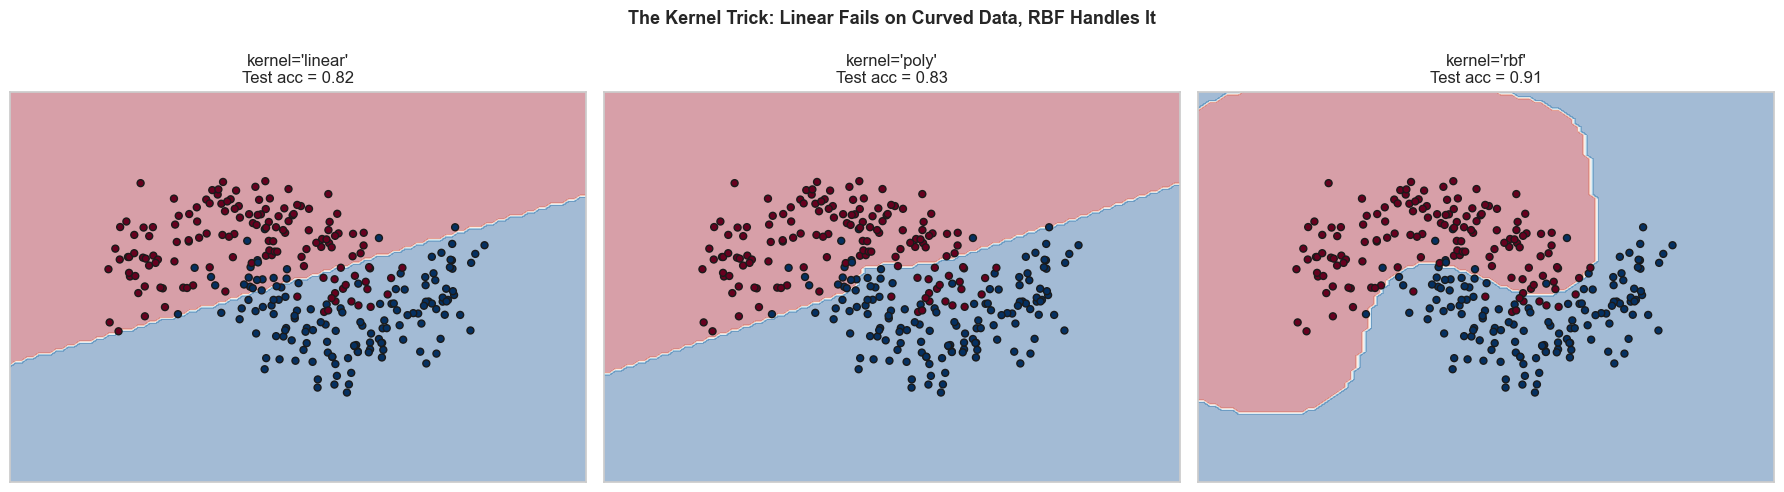

In [10]:
kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, kern in zip(axes, kernels):
    m = make_pipeline(StandardScaler(), SVC(kernel=kern, C=1.0, gamma='scale', random_state=42))
    m.fit(X2d_tr, y2d_tr)
    DecisionBoundaryDisplay.from_estimator(m, X2d, alpha=0.4, ax=ax, cmap='RdBu', response_method='predict')
    ax.scatter(X2d_tr[:, 0], X2d_tr[:, 1], c=y2d_tr, cmap='RdBu', edgecolors='k', s=25)
    acc = accuracy_score(y2d_te, m.predict(X2d_te))
    ax.set_title(f"kernel='{kern}'\nTest acc = {acc:.2f}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('The Kernel Trick: Linear Fails on Curved Data, RBF Handles It', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: Kernels

- **Linear:** one straight cut. It can't follow the moons, so it misclassifies a whole chunk — low accuracy.
- **Poly:** a curved cut; better than linear, but its shape depends heavily on the polynomial degree.
- **RBF:** smooth, closed curves that wrap around each moon — the boundary follows the true shape of the data.

> **Takeaway:** when a straight line clearly won't do, RBF is your default. The "trick" is that SVM finds this
> curved boundary by working in a higher-dimensional space it never explicitly builds — that's what makes it
> both powerful and efficient.


## Step 11 — The C Knob: Soft Margins

Real data is messy — sometimes the classes overlap and no street perfectly separates them. **C** controls how
much the SVM tolerates points inside the margin or on the wrong side:

- **Small C** = a *soft* margin. "I'll allow some mistakes to keep the street wide and smooth." → more bias,
  less variance (guards against overfitting).
- **Large C** = a *hard* margin. "Classify every training point correctly, even if the street gets narrow and
  wiggly." → less bias, more variance (risks overfitting).

C is essentially SVM's **regularization strength** (inverted: bigger C = *less* regularization).


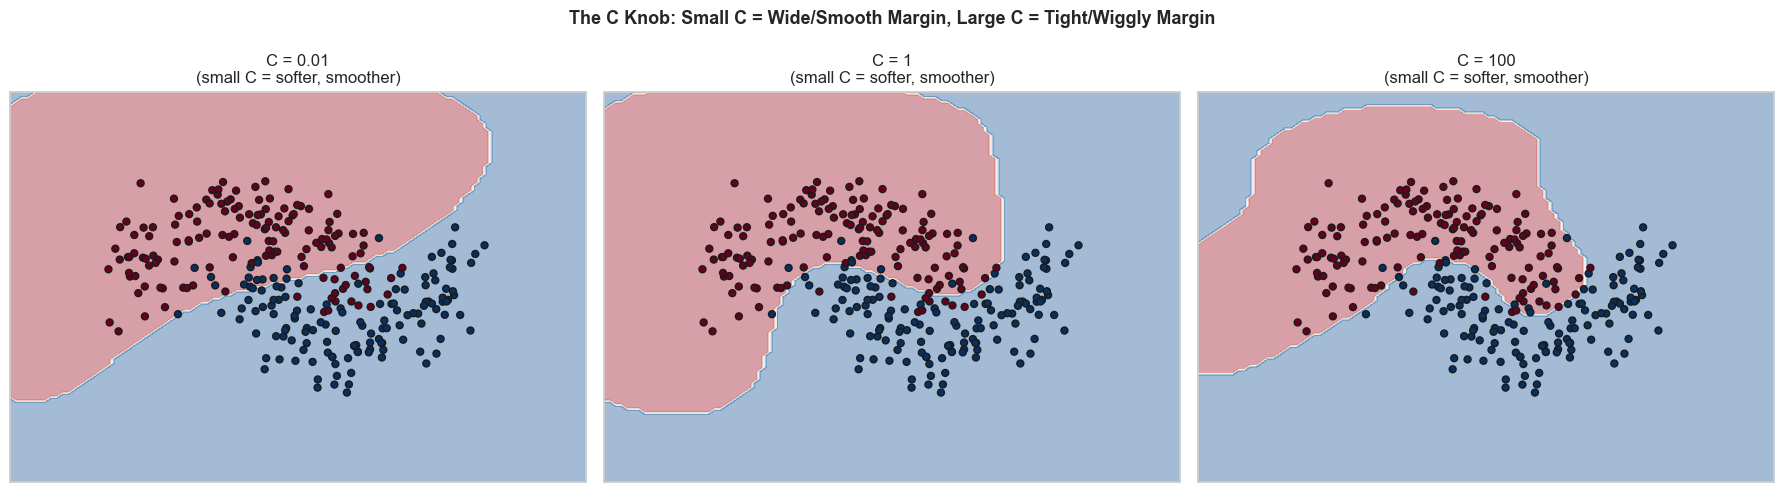

In [11]:
Cs = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, C in zip(axes, Cs):
    m = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma='scale', random_state=42))
    m.fit(X2d_tr, y2d_tr)
    DecisionBoundaryDisplay.from_estimator(m, X2d, alpha=0.4, ax=ax, cmap='RdBu', response_method='predict')
    ax.scatter(X2d_tr[:, 0], X2d_tr[:, 1], c=y2d_tr, cmap='RdBu', edgecolors='k', s=25)
    ax.set_title(f'C = {C}\n(small C = softer, smoother)', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('The C Knob: Small C = Wide/Smooth Margin, Large C = Tight/Wiggly Margin',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: The C Knob
- **C = 0.01:** a very forgiving boundary — smooth, ignores a few points to stay simple (may underfit).
- **C = 1:** a sensible middle ground.
- **C = 100:** the boundary contorts to catch nearly every training point — a sign it may be memorizing noise
  (overfitting). If the C=100 boundary looks more complicated than the data justifies, that's the warning.


## Step 12 — The gamma Knob (RBF kernel)

`gamma` controls **how far a single training point's influence reaches** in the RBF kernel:

- **Small gamma** = far-reaching influence → smooth, broad boundaries (can underfit).
- **Large gamma** = very local influence → the boundary hugs individual points, creating tiny islands
  (classic overfitting).

`C` and `gamma` interact, which is exactly why we tune them **together** in Step 13.


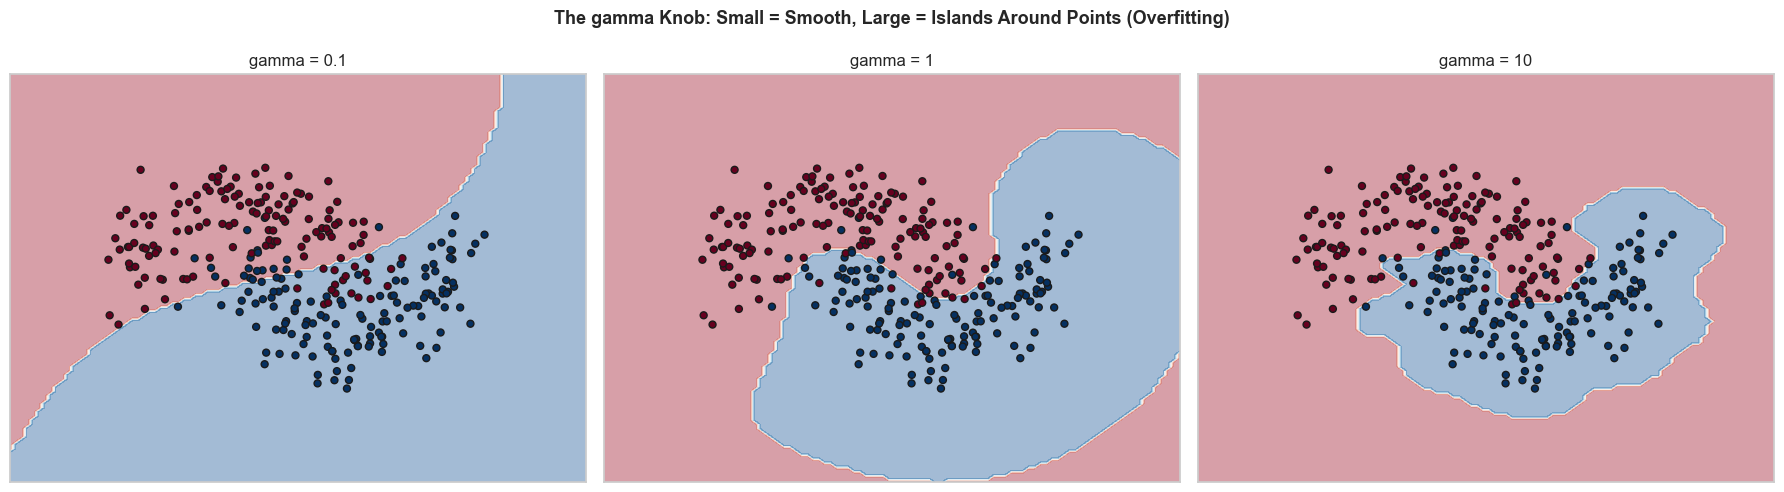

In [12]:
gammas = [0.1, 1, 10]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, g in zip(axes, gammas):
    m = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma=g, random_state=42))
    m.fit(X2d_tr, y2d_tr)
    DecisionBoundaryDisplay.from_estimator(m, X2d, alpha=0.4, ax=ax, cmap='RdBu', response_method='predict')
    ax.scatter(X2d_tr[:, 0], X2d_tr[:, 1], c=y2d_tr, cmap='RdBu', edgecolors='k', s=25)
    ax.set_title(f'gamma = {g}', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('The gamma Knob: Small = Smooth, Large = Islands Around Points (Overfitting)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: The gamma Knob
- **gamma = 0.1:** each point influences a wide area → one smooth, sweeping boundary.
- **gamma = 1:** a good balance that follows the moons.
- **gamma = 10:** each point only influences its immediate surroundings → the model builds little bubbles
  around individual points. High training accuracy, poor generalization — **overfitting**.


## Step 13 — Tuning SVM: Grid Search over C and gamma

Because `C` and `gamma` interact, the standard practice is a **2D grid search** over both, using
cross-validation. We search on a **log scale** (each value 10x the last) because these knobs span orders of
magnitude — the same lesson from the hyperparameter-optimization notebook.


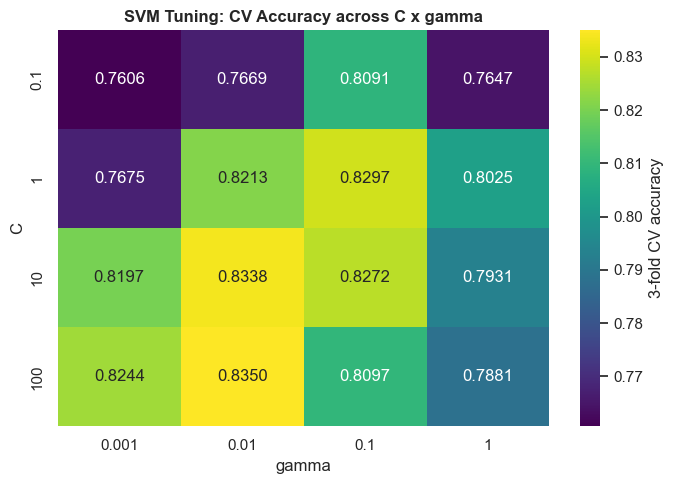

Best params: {'svc__C': 100, 'svc__gamma': 0.01}
Tuned RBF-SVM test accuracy: 0.8413


In [13]:
param_grid = {'svc__C': [0.1, 1, 10, 100], 'svc__gamma': [0.001, 0.01, 0.1, 1]}
pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
# note: pipeline step is named 'svc' by default, hence the 'svc__' prefixes above
grid = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid.fit(X_train_raw, y_train)          # raw data; the pipeline scales internally

# Heatmap of CV accuracy across the C x gamma grid
scores = grid.cv_results_['mean_test_score'].reshape(len(param_grid['svc__C']), len(param_grid['svc__gamma']))
plt.figure(figsize=(7, 5))
sns.heatmap(scores, annot=True, fmt='.4f', cmap='viridis',
            xticklabels=param_grid['svc__gamma'], yticklabels=param_grid['svc__C'],
            cbar_kws={'label': '3-fold CV accuracy'})
plt.xlabel('gamma'); plt.ylabel('C')
plt.title('SVM Tuning: CV Accuracy across C x gamma', fontweight='bold')
plt.tight_layout()
plt.show()

test_acc = accuracy_score(y_test, grid.predict(X_test_raw))
print(f"Best params: {grid.best_params_}")
print(f"Tuned RBF-SVM test accuracy: {test_acc:.4f}")


### How to Read This Chart: SVM Tuning Heatmap
- **Each cell** = one (C, gamma) pair's cross-validated accuracy. Brighter = better.
- **Look for the bright region** — good SVM settings usually form a diagonal band (large C pairs with small
  gamma and vice versa), because the two knobs trade off against each other.
- **Corners are traps:** large C *and* large gamma (bottom-right) tends to overfit; small C *and* small gamma
  (top-left) tends to underfit. The heatmap makes the safe middle obvious.


## Step 14 — SVM for Regression (SVR)

SVM has a regression form, **SVR**. Instead of the widest street *between* classes, SVR fits the flattest tube
of width epsilon *around* the data: points inside the tube incur no penalty, only points outside it do. We
predict Ames prices with an RBF SVR — scaling **both** the features *and* the target (house prices are huge
numbers, and SVR quietly falls apart if the target is not on a reasonable scale).


In [14]:
from sklearn.compose import TransformedTargetRegressor
# SVR is sensitive to the scale of BOTH the features AND the target. Ames prices are in the
# hundreds of thousands, so we standardize X (pipeline) AND y (TransformedTargetRegressor).
svr_pipe = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale'))
svr = TransformedTargetRegressor(regressor=svr_pipe, transformer=StandardScaler())
svr.fit(Xh_train, yh_train)
pred = svr.predict(Xh_test)
print(f"SVR (RBF, with X and y standardized) on Ames:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(yh_test, pred)):,.0f}")
print(f"  R2:   {r2_score(yh_test, pred):.4f}")
print("Lesson: SVR needs its target on a sane scale — without standardizing y, R2 collapses toward 0.")


SVR (RBF, with X and y standardized) on Ames:
  RMSE: $41,943
  R2:   0.7706
Lesson: SVR needs its target on a sane scale — without standardizing y, R2 collapses toward 0.


## Step 15 — k-NN vs SVM: When to Reach for Which

| | **k-NN** | **SVM** |
|---|----------|---------|
| Core idea | Vote among nearest neighbors | Widest-margin boundary + kernel trick |
| Training cost | ~Zero (just memorizes) | Moderate to high (grows with samples) |
| Prediction cost | High (compares to all points) | Low (only support vectors) |
| Scaling required? | **Yes** | **Yes** |
| Key hyperparameters | k, weights, distance metric | C, gamma, kernel |
| Shines when | Small data, low dimensions, simple boundary | Clear margins, curved boundaries, medium data |
| Struggles when | Many features (curse of dimensionality), huge data | Very large datasets (slow to train) |
| Interpretability | Low | Low (kernels are a black box) |

> **Quick rule:** for a fast, dependable baseline on clean tabular data, reach for RBF-SVM (tuned) or k-NN with
> a tuned k. For the *highest* accuracy on tabular data, gradient boosting (notebook 02) usually still wins —
> but these two teach the geometry of learning in a way trees never can, and they remain strong tools for
> smaller problems and as diverse members of an ensemble (notebook 03).


## Step 16 — Summary and Key Takeaways

### The five things to remember

1. **Always scale features for k-NN and SVM.** The single biggest mistake with distance-based models is
   feeding them raw, unscaled features. We saw the accuracy jump in Step 4.
2. **k is k-NN's bias-variance knob.** Small k overfits (jagged boundary), large k underfits (over-smooth).
   Tune it, and prefer odd values for binary problems.
3. **SVM finds the widest-margin boundary, defined only by the support vectors.** Everything else is irrelevant.
4. **The kernel trick lets SVM draw curved boundaries.** RBF is the sensible default; tune **C** (margin
   softness) and **gamma** (influence radius) *together* on a log-scale grid.
5. **Both slow down on big data.** k-NN is slow at prediction time; SVM is slow at training time. Subsample or
   switch to trees/boosting when data gets large.

### Common mistakes to avoid
- **Forgetting to scale** — makes both models near-useless (Step 4).
- **Scaling before the train/test split** — leaks test statistics into training. Always fit the scaler on
  train only (a `Pipeline` does this automatically).
- **Tuning C without gamma (or vice versa)** — they interact; tune the pair.
- **Using k-NN on high-dimensional data** — the curse of dimensionality quietly destroys it (Step 7).

### What's next?
Next in the series: **model interpretability** (opening up these black-box models with SHAP, LIME, and partial
dependence) and **evaluation & threshold selection** (turning any trained model into good decisions).

---

*Notebook by Shivani Bokka — Dive Deeper into Supervised Learning Series*
